<br>

<br>

# Autoscout EDA

## EDA for Car Price Prediction

<br>

<br>! Hello everyone ! <br><br>
This dataset contains many features of 9 different car models.
In this project we are going to prepare this dataset to provide an appropriate input to the ML models.<br>
Thus the steps we are going to follow ;
- Fix the corrupted data formats
- Handle with outliers and missing values.
- Drop the columns/rows you determined unnecessary as a result of your analysis.

<br>
<br> Before start analyzing first let's import the libraries we might use for further steps.

In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from collections import Counter
import warnings
warnings.filterwarnings('ignore')

<br>

In [2]:
df = pd.read_json("scout_car.json", lines = True)

Even though we ussually work on a csv file, this once we are going to be working on a json file. The way that we import it is almost the same with csv file. Only the difference is "lines" parameter.

<br>

- To get an idea of what the data looks like, let's have a look at that by getting some random samples.<br><br>

- I am going to get the tranpose of it to see all the columns.

In [3]:
df.sample(3).T

,6251,12647,1904
url,https://www.autoscout24.com//offers/opel-astra...,https://www.autoscout24.com//offers/opel-insig...,https://www.autoscout24.com//offers/audi-a1-sp...
make_model,Opel Astra,Opel Insignia,Audi A1
short_description,"K Sports Tourer EURO 6,Klima,Intelli Link",Country Tourer 2.0CDTI S&S Aut. 170,SPB 30 TFSI S tronic Admired
body_type,Station wagon,Off-Road,Sedans
price,8990,31505,27650
vat,VAT deductible,None,VAT deductible
km,"114,000 km",- km,- km
registration,10/2016,-/-,04/2019
prev_owner,1 previous owner,None,None
kW,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15919 entries, 0 to 15918
Data columns (total 54 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   url                            15919 non-null  object 
 1   make_model                     15919 non-null  object 
 2   short_description              15873 non-null  object 
 3   body_type                      15859 non-null  object 
 4   price                          15919 non-null  int64  
 5   vat                            11406 non-null  object 
 6   km                             15919 non-null  object 
 7   registration                   15919 non-null  object 
 8   prev_owner                     9091 non-null   object 
 9   kW                             0 non-null      float64
 10  hp                             15919 non-null  object 
 11  Type                           15917 non-null  object 
 12  Previous Owners                9279 non-null  

In [5]:
df.isnull().sum()

url                                  0
make_model                           0
short_description                   46
body_type                           60
price                                0
vat                               4513
km                                   0
registration                         0
prev_owner                        6828
kW                               15919
hp                                   0
Type                                 2
Previous Owners                   6640
Next Inspection                  12384
Inspection new                   11987
Warranty                          5420
Full Service                      7704
Non-smoking Vehicle               8742
null                                 0
Make                                 0
Model                                0
Offer Number                      3175
First Registration                1597
Body Color                         597
Paint Type                        5772
Body Color Original      

<br>I am not happy to say that but this dataset is __chaotic__ !! We have got a lot to do, better to get started.<br><br>

In [6]:
df1 = df.copy()

#### Dropping the column which have more than %50 null values.

In [7]:
df1.drop('kW', axis = 1, inplace = True)
df1.drop('Next Inspection', axis = 1, inplace = True)
df1.drop('Inspection new', axis = 1, inplace = True)
df1.drop('Non-smoking Vehicle', axis = 1, inplace = True)
df1.drop('null', axis = 1, inplace = True)
df1.drop('Model Code', axis = 1, inplace = True)
df1.drop('Emission Label', axis = 1, inplace = True)
df1.drop('Full Service', axis = 1, inplace = True)
df1.drop('Electricity consumption', axis = 1, inplace = True)
df1.drop('Last Service Date', axis = 1, inplace = True)
df1.drop('Other Fuel Types', axis = 1, inplace = True)
df1.drop('Availability', axis = 1, inplace = True)
df1.drop('Last Timing Belt Service Date', axis = 1, inplace = True)
df1.drop('Available from', axis = 1, inplace = True)

<br>

- Let's shoot a glance to each column one by one.

In [8]:
df1.columns

Index(['url', 'make_model', 'short_description', 'body_type', 'price', 'vat',
       'km', 'registration', 'prev_owner', 'hp', 'Type', 'Previous Owners',
       'Warranty', 'Make', 'Model', 'Offer Number', 'First Registration',
       'Body Color', 'Paint Type', 'Body Color Original', 'Upholstery', 'Body',
       'Nr. of Doors', 'Nr. of Seats', 'Gearing Type', 'Displacement',
       'Cylinders', 'Weight', 'Drive chain', 'Fuel', 'Consumption',
       'CO2 Emission', 'Emission Class', '\nComfort & Convenience\n',
       '\nEntertainment & Media\n', '\nExtras\n', '\nSafety & Security\n',
       'description', 'Gears', 'Country version'],
      dtype='object')

### Url

In [9]:
df1.drop('url', axis = 1, inplace = True)

In [10]:
df1.columns

Index(['make_model', 'short_description', 'body_type', 'price', 'vat', 'km',
       'registration', 'prev_owner', 'hp', 'Type', 'Previous Owners',
       'Warranty', 'Make', 'Model', 'Offer Number', 'First Registration',
       'Body Color', 'Paint Type', 'Body Color Original', 'Upholstery', 'Body',
       'Nr. of Doors', 'Nr. of Seats', 'Gearing Type', 'Displacement',
       'Cylinders', 'Weight', 'Drive chain', 'Fuel', 'Consumption',
       'CO2 Emission', 'Emission Class', '\nComfort & Convenience\n',
       '\nEntertainment & Media\n', '\nExtras\n', '\nSafety & Security\n',
       'description', 'Gears', 'Country version'],
      dtype='object')

### make_model

In [11]:
df1.make_model.value_counts(dropna = False)

Audi A3           3097
Audi A1           2614
Opel Insignia     2598
Opel Astra        2526
Opel Corsa        2219
Renault Clio      1839
Renault Espace     991
Renault Duster      34
Audi A2              1
Name: make_model, dtype: int64

In [12]:
df1.rename(columns={'make_model':'Make_Model'}, inplace = True)

### short_description

In [13]:
df1.drop('short_description', axis = 1, inplace = True)

In [14]:
df1.columns

Index(['Make_Model', 'body_type', 'price', 'vat', 'km', 'registration',
       'prev_owner', 'hp', 'Type', 'Previous Owners', 'Warranty', 'Make',
       'Model', 'Offer Number', 'First Registration', 'Body Color',
       'Paint Type', 'Body Color Original', 'Upholstery', 'Body',
       'Nr. of Doors', 'Nr. of Seats', 'Gearing Type', 'Displacement',
       'Cylinders', 'Weight', 'Drive chain', 'Fuel', 'Consumption',
       'CO2 Emission', 'Emission Class', '\nComfort & Convenience\n',
       '\nEntertainment & Media\n', '\nExtras\n', '\nSafety & Security\n',
       'description', 'Gears', 'Country version'],
      dtype='object')

### body_type

In [15]:
df1.body_type.value_counts(dropna = False)

Sedans           7903
Station wagon    3553
Compact          3153
Van               783
Other             290
Transporter        88
NaN                60
Off-Road           56
Coupe              25
Convertible         8
Name: body_type, dtype: int64

In [16]:
df1.rename(columns={'body_type':'Body_Type'}, inplace = True)

### price

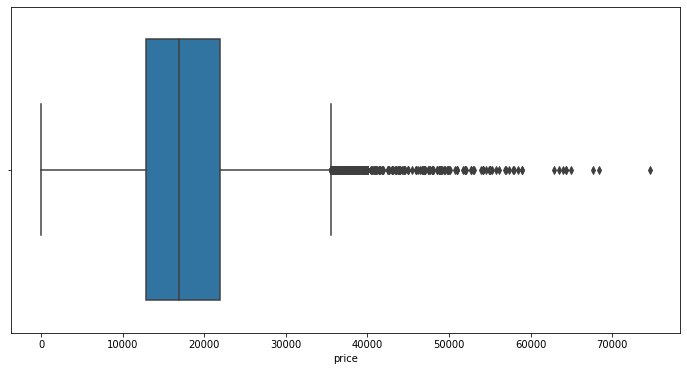

In [17]:
plt.figure(figsize = (12,6))
sns.boxplot(df1.price);

In [18]:
df1.price.sort_values().head(10)

8594       13
8828      120
6066      255
8829      331
8827     4950
8825     4990
8826     5250
8824     5300
13770    5445
8823     5450
Name: price, dtype: int64

In [19]:
df1.price.sort_values(ascending=False).head(10)

3648     74600
15826    68320
3649     67600
3587     64900
15828    64332
15831    64298
3595     63900
15833    63477
3590     62900
3594     58990
Name: price, dtype: int64

In [20]:
df1.rename(columns={'price':'Price'}, inplace = True)

### vat

In [21]:
df1.vat.value_counts(dropna = False)

VAT deductible      10980
NaN                  4513
Price negotiable      426
Name: vat, dtype: int64

In [22]:
def vat_bool (i):
        if i == "VAT deductible":
             return True
        else :
            return False

In [23]:
df1.vat = df1.vat.apply(vat_bool)

In [24]:
df1.rename(columns={'vat':'Vat_Deductible'}, inplace = True)

In [25]:
df1.columns

Index(['Make_Model', 'Body_Type', 'Price', 'Vat_Deductible', 'km',
       'registration', 'prev_owner', 'hp', 'Type', 'Previous Owners',
       'Warranty', 'Make', 'Model', 'Offer Number', 'First Registration',
       'Body Color', 'Paint Type', 'Body Color Original', 'Upholstery', 'Body',
       'Nr. of Doors', 'Nr. of Seats', 'Gearing Type', 'Displacement',
       'Cylinders', 'Weight', 'Drive chain', 'Fuel', 'Consumption',
       'CO2 Emission', 'Emission Class', '\nComfort & Convenience\n',
       '\nEntertainment & Media\n', '\nExtras\n', '\nSafety & Security\n',
       'description', 'Gears', 'Country version'],
      dtype='object')

### km

In [26]:
df1.km.value_counts()

10 km         1045
- km          1024
1 km           367
5 km           170
50 km          148
              ... 
6,305 km         1
119,329 km       1
21,654 km        1
149,915 km       1
75,427 km        1
Name: km, Length: 6690, dtype: int64

In [27]:
df1.rename(columns={'km':'Km'}, inplace = True)

In [28]:
df1.Km = df1.Km.astype('str').replace('- km', np.nan)
df1.Km  = df1.Km.str.strip(" km")
df1.Km = df1.Km.str.replace(",", "")
df1.Km = df1.Km.astype(float)

In [29]:
df1.Km

0        56013.0
1        80000.0
2        83450.0
3        73000.0
4        16200.0
          ...   
15914        NaN
15915     9900.0
15916       15.0
15917       10.0
15918        NaN
Name: Km, Length: 15919, dtype: float64

### registration & First Registration

In [30]:
df1.registration.value_counts()

-/-        1597
03/2018     695
02/2019     585
05/2018     572
03/2019     543
04/2018     541
01/2019     541
02/2018     539
03/2016     536
06/2018     532
04/2016     532
01/2018     511
04/2019     506
02/2016     472
03/2017     471
05/2016     459
06/2016     452
05/2019     440
06/2017     409
05/2017     404
07/2018     396
04/2017     380
01/2016     376
02/2017     368
01/2017     306
08/2018     285
06/2019     224
07/2017     215
11/2017     180
07/2016     176
10/2016     160
10/2017     154
09/2017     149
11/2016     142
09/2016     141
09/2018     141
12/2016     134
12/2017     123
08/2017     114
11/2018     110
12/2018     103
10/2018      97
08/2016      94
07/2019       6
09/2019       5
12/2019       1
08/2019       1
11/2019       1
Name: registration, dtype: int64

In [31]:
df1.drop('registration', axis = 1, inplace = True)

In [32]:
df1['First Registration'] = df1['First Registration'].str[1].astype('float')

In [33]:
df1['First Registration'].value_counts(dropna = False)

2018.0    4522
2016.0    3674
2017.0    3273
2019.0    2853
NaN       1597
Name: First Registration, dtype: int64

In [34]:
df1['First Registration'] = 2019 - df1['First Registration']

In [35]:
df1.rename(columns={'First Registration':'Age'}, inplace = True)

In [36]:
df1.Age.value_counts()

1.0    4522
3.0    3674
2.0    3273
0.0    2853
Name: Age, dtype: int64

In [37]:
df1.columns

Index(['Make_Model', 'Body_Type', 'Price', 'Vat_Deductible', 'Km',
       'prev_owner', 'hp', 'Type', 'Previous Owners', 'Warranty', 'Make',
       'Model', 'Offer Number', 'Age', 'Body Color', 'Paint Type',
       'Body Color Original', 'Upholstery', 'Body', 'Nr. of Doors',
       'Nr. of Seats', 'Gearing Type', 'Displacement', 'Cylinders', 'Weight',
       'Drive chain', 'Fuel', 'Consumption', 'CO2 Emission', 'Emission Class',
       '\nComfort & Convenience\n', '\nEntertainment & Media\n', '\nExtras\n',
       '\nSafety & Security\n', 'description', 'Gears', 'Country version'],
      dtype='object')

### prev_owner & Previous Owners

In [38]:
df1.prev_owner.value_counts(dropna = False)

1 previous owner     8294
NaN                  6828
2 previous owners     778
3 previous owners      17
4 previous owners       2
Name: prev_owner, dtype: int64

In [39]:
df1['Previous Owners'].value_counts(dropna = False)

TypeError: unhashable type: 'list'

Exception ignored in: 'pandas._libs.index.IndexEngine._call_map_locations'
Traceback (most recent call last):
  File "pandas\_libs\hashtable_class_helper.pxi", line 4588, in pandas._libs.hashtable.PyObjectHashTable.map_locations
TypeError: unhashable type: 'list'


\n1\n                                                                                        8101
NaN                                                                                          6640
\n2\n                                                                                         766
\n0\n                                                                                         163
\n3\n                                                                                          17
                                                                                             ... 
[\n1\n, \n, 5.6 l/100 km (comb), \n, 7.3 l/100 km (city), \n, 4.7 l/100 km (country), \n]       1
[\n0\n, \n117 g CO2/km (comb)\n]                                                                1
[\n1\n, \n141 g CO2/km (comb)\n]                                                                1
[\n1\n, \n, 5.9 l/100 km (comb), \n, 7.6 l/100 km (city), \n, 4.9 l/100 km (country), \n]       1
[\n1\n, \n102 g CO2/

In [40]:
df1.drop('Previous Owners', axis = 1, inplace = True)

In [41]:
df1.prev_owner.str.strip(' previous owners').value_counts()

1    8294
2     778
3      17
4       2
Name: prev_owner, dtype: int64

In [42]:
df1.prev_owner = df1.prev_owner.str.strip(' previous owners')

In [43]:
df1.prev_owner.value_counts(dropna = False)

1      8294
NaN    6828
2       778
3        17
4         2
Name: prev_owner, dtype: int64

In [44]:
df1.rename(columns={'prev_owner':'Previous_Owners'}, inplace = True)

In [45]:
df1.columns

Index(['Make_Model', 'Body_Type', 'Price', 'Vat_Deductible', 'Km',
       'Previous_Owners', 'hp', 'Type', 'Warranty', 'Make', 'Model',
       'Offer Number', 'Age', 'Body Color', 'Paint Type',
       'Body Color Original', 'Upholstery', 'Body', 'Nr. of Doors',
       'Nr. of Seats', 'Gearing Type', 'Displacement', 'Cylinders', 'Weight',
       'Drive chain', 'Fuel', 'Consumption', 'CO2 Emission', 'Emission Class',
       '\nComfort & Convenience\n', '\nEntertainment & Media\n', '\nExtras\n',
       '\nSafety & Security\n', 'description', 'Gears', 'Country version'],
      dtype='object')

### hp

In [46]:
df1.hp.value_counts()

85 kW     2542
66 kW     2122
81 kW     1402
100 kW    1308
110 kW    1112
          ... 
84 kW        1
132 kW       1
195 kW       1
239 kW       1
44 kW        1
Name: hp, Length: 81, dtype: int64

In [47]:
df1.hp = df1.hp.replace('- kW', np.nan)
df1.hp = df1.hp.str.strip(" kW").astype('float')
df1.rename(columns={'hp':'kW'}, inplace = True )
df1.kW.value_counts(dropna = False)

85.0     2542
66.0     2122
81.0     1402
100.0    1308
110.0    1112
         ... 
239.0       1
115.0       1
163.0       1
4.0         1
75.0        1
Name: kW, Length: 81, dtype: int64

In [48]:
df1.kW.isnull().sum()

88

In [49]:
df1.columns

Index(['Make_Model', 'Body_Type', 'Price', 'Vat_Deductible', 'Km',
       'Previous_Owners', 'kW', 'Type', 'Warranty', 'Make', 'Model',
       'Offer Number', 'Age', 'Body Color', 'Paint Type',
       'Body Color Original', 'Upholstery', 'Body', 'Nr. of Doors',
       'Nr. of Seats', 'Gearing Type', 'Displacement', 'Cylinders', 'Weight',
       'Drive chain', 'Fuel', 'Consumption', 'CO2 Emission', 'Emission Class',
       '\nComfort & Convenience\n', '\nEntertainment & Media\n', '\nExtras\n',
       '\nSafety & Security\n', 'description', 'Gears', 'Country version'],
      dtype='object')

### Type

In [50]:
df1.Type.value_counts(dropna = False)

TypeError: unhashable type: 'list'

Exception ignored in: 'pandas._libs.index.IndexEngine._call_map_locations'
Traceback (most recent call last):
  File "pandas\_libs\hashtable_class_helper.pxi", line 4588, in pandas._libs.hashtable.PyObjectHashTable.map_locations
TypeError: unhashable type: 'list'


[, Used, , Diesel (Particulate Filter)]                                                                                 3475
[, Used, , Diesel]                                                                                                      2516
[, Used, , Gasoline]                                                                                                    2367
[, Used, , Super 95]                                                                                                    1818
[, Pre-registered, , Super 95]                                                                                           500
                                                                                                                        ... 
[, Pre-registered, , CNG]                                                                                                  1
[, Used, , Others (Particulate Filter)]                                                                                    1


In [51]:
df1.Type = df1.Type.str[1]

In [52]:
df1.Type.value_counts(dropna = False)

Used              11096
New                1650
Pre-registered     1364
Employee's car     1011
Demonstration       796
NaN                   2
Name: Type, dtype: int64

In [53]:
df1.sample(3).T

,1307,10249,1158
Make_Model,Audi A1,Opel Corsa,Audi A1
Body_Type,Compact,Sedans,Sedans
Price,15740,10790,18950
Vat_Deductible,True,True,False
Km,4990.0,NaN,18950.0
Previous_Owners,1,1,1
kW,60.0,55.0,92.0
Type,Used,Demonstration,Used
Warranty,"[\n, \n, \nEuro 6\n]","[\n, \n, \nEuro 6\n]","[\n, \n, \nEuro 6\n]"
Make,\nAudi\n,\nOpel\n,\nAudi\n


### Warranty

In [54]:
df1.Warranty.value_counts(dropna = False)

TypeError: unhashable type: 'list'

Exception ignored in: 'pandas._libs.index.IndexEngine._call_map_locations'
Traceback (most recent call last):
  File "pandas\_libs\hashtable_class_helper.pxi", line 4588, in pandas._libs.hashtable.PyObjectHashTable.map_locations
TypeError: unhashable type: 'list'


NaN                                                                                           5420
[\n, \n, \nEuro 6\n]                                                                          1868
\n12 months\n                                                                                 1177
\n                                                                                             979
\n24 months\n                                                                                  566
                                                                                              ... 
[\n, \n, \n, 4.4 l/100 km (comb), \n, 5.2 l/100 km (city), \n, 3.9 l/100 km (country), \n]       1
[\n60 months\n, \n120 g CO2/km (comb)\n]                                                         1
[\n60 months\n, \n146 g CO2/km (comb)\n]                                                         1
[\n60 months\n, \nEuro 6d\n]                                                                     1
[\n72 mont

In [55]:
df1["Warranty"] = df1.Warranty.apply(lambda x : x[0] if type(x)==list else x)

In [56]:
df1.Warranty.value_counts(dropna = False)
df1.Warranty = df1.Warranty.replace('\n', np.nan)

In [57]:
df1.Warranty.value_counts(dropna = False)

NaN              11065
\n12 months\n     2594
\n24 months\n     1118
\n60 months\n      401
\n36 months\n      279
\n48 months\n      149
\n6 months\n       125
\n72 months\n       59
\n3 months\n        33
\n23 months\n       11
\n18 months\n       10
\n20 months\n        7
\n25 months\n        6
\n2 months\n         5
\n16 months\n        4
\n50 months\n        4
\n26 months\n        4
\n4 months\n         3
\n19 months\n        3
\n1 months\n         3
\n34 months\n        3
\n13 months\n        3
\n21 months\n        2
\n11 months\n        2
\n14 months\n        2
\n28 months\n        2
\n17 months\n        2
\n46 months\n        2
\n45 months\n        2
\n9 months\n         2
\n22 months\n        2
\n49 months\n        1
\n40 months\n        1
\n8 months\n         1
\n65 months\n        1
\n7 months\n         1
\n15 months\n        1
\n47 months\n        1
\n56 months\n        1
\n10 months\n        1
\n33 months\n        1
\n30 months\n        1
                     1
Name: Warra

In [58]:
df1.Warranty = df1.Warranty.str.strip('\n').str.strip(' months')

In [59]:
df1.Warranty.value_counts(dropna = False)

NaN    11065
12      2594
24      1118
60       401
36       279
48       149
6        125
72        59
3         33
23        11
18        10
20         7
25         6
2          5
50         4
26         4
16         4
1          3
13         3
34         3
19         3
4          3
9          2
28         2
46         2
21         2
45         2
11         2
22         2
14         2
17         2
30         1
15         1
33         1
           1
7          1
10         1
47         1
49         1
8          1
65         1
40         1
56         1
Name: Warranty, dtype: int64

In [60]:
df1.Warranty = df1.Warranty.replace("", np.nan)

In [61]:
df1.Warranty = df1.Warranty.astype('float')

In [62]:
df1.Price.corr(df1.Warranty)

0.20352098768435753

<AxesSubplot:xlabel='Price', ylabel='Warranty'>

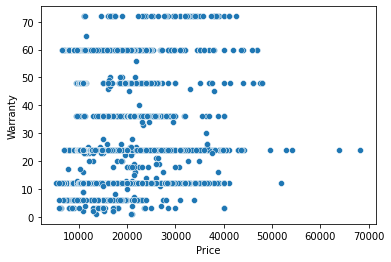

In [63]:
sns.scatterplot(y = df1.Warranty, x = df1.Price)

In [64]:
df1.columns

Index(['Make_Model', 'Body_Type', 'Price', 'Vat_Deductible', 'Km',
       'Previous_Owners', 'kW', 'Type', 'Warranty', 'Make', 'Model',
       'Offer Number', 'Age', 'Body Color', 'Paint Type',
       'Body Color Original', 'Upholstery', 'Body', 'Nr. of Doors',
       'Nr. of Seats', 'Gearing Type', 'Displacement', 'Cylinders', 'Weight',
       'Drive chain', 'Fuel', 'Consumption', 'CO2 Emission', 'Emission Class',
       '\nComfort & Convenience\n', '\nEntertainment & Media\n', '\nExtras\n',
       '\nSafety & Security\n', 'description', 'Gears', 'Country version'],
      dtype='object')

### Make - Model

- Since we have make_model column which is more than enough for us, we can drop both make and model columns.

In [65]:
df1.drop(['Make', 'Model'],axis = 1, inplace = True )

In [66]:
df1.columns

Index(['Make_Model', 'Body_Type', 'Price', 'Vat_Deductible', 'Km',
       'Previous_Owners', 'kW', 'Type', 'Warranty', 'Offer Number', 'Age',
       'Body Color', 'Paint Type', 'Body Color Original', 'Upholstery', 'Body',
       'Nr. of Doors', 'Nr. of Seats', 'Gearing Type', 'Displacement',
       'Cylinders', 'Weight', 'Drive chain', 'Fuel', 'Consumption',
       'CO2 Emission', 'Emission Class', '\nComfort & Convenience\n',
       '\nEntertainment & Media\n', '\nExtras\n', '\nSafety & Security\n',
       'description', 'Gears', 'Country version'],
      dtype='object')

### Offer Number

In [67]:
df1['Offer Number'].value_counts(dropna = False)

TypeError: unhashable type: 'list'

Exception ignored in: 'pandas._libs.index.IndexEngine._call_map_locations'
Traceback (most recent call last):
  File "pandas\_libs\hashtable_class_helper.pxi", line 4588, in pandas._libs.hashtable.PyObjectHashTable.map_locations
TypeError: unhashable type: 'list'


NaN                3175
[\nXT61649\n]        27
[\nHM53619\n]        27
[\nTP62881\n]        27
[\nJV03654\n]        27
                   ... 
[\n9277941\n]         1
[\n19155-1\n]         1
[\n3124254\n]         1
[\nJ1109546\n]        1
[\n040394-MO\n]       1
Name: Offer Number, Length: 11441, dtype: int64

In [68]:
df1.drop('Offer Number', axis = 1, inplace = True)

In [69]:
df1.columns

Index(['Make_Model', 'Body_Type', 'Price', 'Vat_Deductible', 'Km',
       'Previous_Owners', 'kW', 'Type', 'Warranty', 'Age', 'Body Color',
       'Paint Type', 'Body Color Original', 'Upholstery', 'Body',
       'Nr. of Doors', 'Nr. of Seats', 'Gearing Type', 'Displacement',
       'Cylinders', 'Weight', 'Drive chain', 'Fuel', 'Consumption',
       'CO2 Emission', 'Emission Class', '\nComfort & Convenience\n',
       '\nEntertainment & Media\n', '\nExtras\n', '\nSafety & Security\n',
       'description', 'Gears', 'Country version'],
      dtype='object')

### Body Color

In [70]:
df1['Body Color'] = df1['Body Color'].str[1]

In [71]:
df1['Body Color'].value_counts(dropna = False)

Black     3745
Grey      3505
White     3406
Silver    1647
Blue      1431
Red        957
NaN        597
Brown      289
Green      154
Beige      108
Yellow      51
Violet      18
Bronze       6
Orange       3
Gold         2
Name: Body Color, dtype: int64

### Paint Type

In [72]:
df1['Paint Type'].value_counts(dropna = False)

TypeError: unhashable type: 'list'

Exception ignored in: 'pandas._libs.index.IndexEngine._call_map_locations'
Traceback (most recent call last):
  File "pandas\_libs\hashtable_class_helper.pxi", line 4588, in pandas._libs.hashtable.PyObjectHashTable.map_locations
TypeError: unhashable type: 'list'


[\nMetallic\n]       9794
NaN                  5772
[\nUni/basic\n]       347
[\nPerl effect\n]       6
Name: Paint Type, dtype: int64

In [73]:
df1['Paint Type'] = df1['Paint Type'].str[0].str.strip('\n')

In [74]:
df1.rename(columns={'Paint Type':'Paint_Type'}, inplace = True)

### Body Color Original

In [75]:
df1['Body Color Original']

0                 [\nMythosschwarz\n]
1                                 NaN
2        [\nmythosschwarz metallic\n]
3                                 NaN
4        [\nMythosschwarz Metallic\n]
                     ...             
15914              [\nGrigio scuro\n]
15915       [\nStahl-Grau Metallic\n]
15916               [\narktis-weiß\n]
15917                    [\nGrigio\n]
15918    [\nTitanium-Grau Metallic\n]
Name: Body Color Original, Length: 15919, dtype: object

In [76]:
df1.drop('Body Color Original', axis = 1, inplace = True)

In [77]:
df1.columns

Index(['Make_Model', 'Body_Type', 'Price', 'Vat_Deductible', 'Km',
       'Previous_Owners', 'kW', 'Type', 'Warranty', 'Age', 'Body Color',
       'Paint_Type', 'Upholstery', 'Body', 'Nr. of Doors', 'Nr. of Seats',
       'Gearing Type', 'Displacement', 'Cylinders', 'Weight', 'Drive chain',
       'Fuel', 'Consumption', 'CO2 Emission', 'Emission Class',
       '\nComfort & Convenience\n', '\nEntertainment & Media\n', '\nExtras\n',
       '\nSafety & Security\n', 'description', 'Gears', 'Country version'],
      dtype='object')

### Upholstery

In [78]:
df1.Upholstery.str[0].value_counts(dropna = False)

\nCloth, Black\n           5821
NaN                        3720
\nPart leather, Black\n    1121
\nCloth\n                  1005
\nCloth, Grey\n             891
\nCloth, Other\n            639
\nFull leather, Black\n     575
\nBlack\n                   491
\nGrey\n                    273
\nOther, Other\n            182
\nPart leather\n            140
\nFull leather\n            139
\nFull leather, Brown\n     116
\nPart leather, Grey\n      116
\nOther, Black\n            110
\nFull leather, Other\n      72
\nFull leather, Grey\n       67
\nPart leather, Other\n      65
\nOther\n                    56
\nPart leather, Brown\n      50
\nalcantara, Black\n         47
\nFull leather, Beige\n      36
\nVelour, Black\n            36
\nCloth, Brown\n             28
\nVelour\n                   16
\nOther, Grey\n              15
\nCloth, Beige\n             13
\nBrown\n                    12
\nCloth, Blue\n              12
\nCloth, White\n              8
\nVelour, Grey\n              8
\nalcant

In [79]:
df1.Upholstery = df1.Upholstery.str[0]

In [156]:
type(df1.Upholstery[3])

float

In [80]:
df1.Upholstery = df1.Upholstery.str.strip('\n')

In [157]:
def Up_type(x):
    if type(x) != float :
        if ('Cloth' in x) or ("Cloth," in x):
            return 'Cloth'
        elif ('Part leather' in x) or ('Part leather,' in x):
            return 'Part leather'
        elif ('Full leather' in x) or ('Full leather,' in x):
            return 'Full leather'
        elif ('alcantara' in x) or ('alcantara,' in x):
            return 'Alcantara'
        elif ('Velour' in x)or ('Velour,' in x) :
            return 'Velour'
        else :
            return 'Other'
    else:
        return x

In [161]:
df1.Upholstery.apply(Up_type).value_counts(dropna = False)

Cloth           8423
NaN             3720
Part leather    1499
Other           1151
Full leather    1009
Velour            60
Alcantara         57
Name: Upholstery, dtype: int64

In [162]:
df1.Upholstery = df1.Upholstery.apply(Up_type)